## CIFAR-10 reversal

In [1]:
import h5py
import os, json, math, gc, random
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import tensorflow as tf
import json
import os
import numpy as np
import json
import os


with h5py.File('/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/CIFAR_P_RESULTS/H64_Probing/model_PROBE_CIFAR_PROBE_260422_0951.weights.h5', 'r') as f:
    print("--- Layer Parameters ---")
    # Dig into the layers hierarchy
    layers = f['layers']
    for layer_name in layers.keys():
        print(f"\nLayer: {layer_name}")
        # Keras 3 often nests weights under a 'vars' or 'weights' sub-group
        weights_group = layers[layer_name]['vars'] 
        for weight_name in weights_group.keys():
            data = weights_group[weight_name][()]
            print(f"  {weight_name}: {data.shape} | Total: {np.prod(data.shape)}")

2026-06-22 12:03:31.555139: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-22 12:03:31.654498: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782093811.678663  150138 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782093811.688438  150138 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782093811.777862  150138 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

--- Layer Parameters ---

Layer: dense
  0: (64, 10) | Total: 640
  1: (10,) | Total: 10

Layer: input_layer

Layer: rnn

Layer: rnn_1

Layer: rnn_2


In [2]:
import os, json, math, gc, random
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import tensorflow as tf
import json
import os
import numpy as np
import json
import os

def load_json(cfg_key, cond):
    """Load the JSON result file for a specific config and condition."""
    cfg = CONFIGS[cfg_key]
    folder = cfg['folder']
    filename = cfg['json'].get(cond)
    
    if not filename:
        print(f"     No JSON filename defined for {cfg_key} | {cond}")
        return None
        
    path = os.path.join(folder, filename)
    
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    else:
        print(f"     File not found: {path}")
        return None

# Suppress TF noise
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.keras.mixed_precision.set_global_policy('float32')
print('TF:', tf.__version__)

"""Return dict of numpy arrays from a loaded JSON result."""
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def extract_series(data):
    """Return dict of numpy arrays from a loaded JSON result with normalized keys."""
    # 1. Locate history list
    h_list = data.get('history') or data.get('epochs')
    if h_list is None: return None

    # 2. Extract raw metrics based on structure
    if isinstance(h_list, dict):  # sMNIST/psMNIST style (dict of lists)
        raw_h = h_list
        epochs = np.arange(1, len(raw_h['loss']) + 1)
        loss = np.array(raw_h['loss'])
        val_metric = np.array(raw_h.get('acc') or raw_h.get('mse') or [0])
        
        # Flatten hidden_metrics if they exist
        if 'hidden_metrics' in raw_h and len(raw_h['hidden_metrics']) > 0:
            extracted_metrics = {k: np.array([m[k] for m in raw_h['hidden_metrics']])
                                 for k in raw_h['hidden_metrics'][0]}
        else:
            extracted_metrics = {}
    else:  # Adding/CIFAR style (list of dicts)
        epochs = np.array([e['epoch'] for e in h_list])
        loss = np.array([e.get('loss') or e.get('mse') for e in h_list])
        val_metric = np.array([e.get('acc') or e.get('mse') for e in h_list])
        
        excluded = {'epoch', 'loss', 'mse', 'acc'}
        metric_keys = [k for k in h_list[0].keys() if k not in excluded]
        extracted_metrics = {k: np.array([e[k] for e in h_list]) for k in metric_keys}

    # 3. NORMALIZE KEYS (Map sMNIST long names to short names used in plotting)
    key_map = {
        'effective_rank': 'rank',
        'synchrony':      'sync',
        'interference':   'intf',
        'entropy':        'entr'
    }
    normalized_metrics = {}
    for k, v in extracted_metrics.items():
        norm_k = key_map.get(k, k) # Use map if exists, else keep original
        normalized_metrics[norm_k] = v

    # 4. Handle Accuracy/MSE for test results
    # Check all common variants of the test result key
    test_val = (data.get('test_acc') or data.get('test_accuracy') or 
                data.get('test_mse') or data.get('test_loss') or 0.0)
    
    # Auto-scale accuracy to % (0.85 -> 85.0)
    is_acc = any(k in data for k in ['test_acc', 'test_accuracy', 'acc'])
    test_result_final = test_val * 100 if (is_acc and test_val <= 1.0) else test_val

    return {
        'epochs':       epochs,
        'loss':         loss,
        'val_metric':   val_metric * 100 if (is_acc and val_metric[0] <= 1.0) else val_metric,
        'test_acc':     test_result_final, 
        'config':       data.get('parameters', data.get('config')),
        **normalized_metrics
    }

TF: 2.19.1


In [3]:
# ------------------------------------------------------------------ #
#  EDIT: set the four root folders for each experiment configuration  #
# ------------------------------------------------------------------ #
BASE = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation'

CONFIGS = {
    'psMNIST-H32': {
        'folder': f'{BASE}/PMNIST/h32',
        'hidden': 32,
        'benchmark': 'psMNIST',
        'permuted': True,
        # Session IDs for each condition (edit to match your filenames)
        'sessions': {
            'Active':  'RES_H32_S0.13_J1_260221_2142',
            'Passive': 'RES_H32_S0.13_J1_260222_1954',
            'Probe':   'RES_H32_S0.13_J1_260222_1954',
        },
        # Exact weight file names (with copy suffixes etc.)
        'weights': {
            'Active':  'best_RES_H32_S0.13_J1_260221_2142_active.weights.h5',
            'Passive': 'best_RES_H32_S0.13_J1_260222_1954_passive.weights.h5',
            'Probe':   'best_RES_H32_S0.13_J1_260222_1954_probe.weights.h5',
        },
        'json': {
            'Active':  'results_RES_H32_S0.13_J1_260221_2142_Active.json',
            'Passive': 'results_RES_H32_S0.13_J1_260222_1954_Passive.json',
            'Probe':   'results_RES_H32_S0.13_J1_260222_1954_Probe.json',
        },
        # Hyperparams used during this run
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
    'psMNIST-H16': {
        'folder': f'{BASE}/PMNIST/h16',
        'hidden': 16,
        'benchmark': 'psMNIST',
        'permuted': True,
        'sessions': {
            'Active':  'RES_H16_S0.13_J0.65_260223_1436',  
            'Passive': 'RES_H16_S0.13_J0.65_260223_1436',
            'Probe':   'RES_H16_S0.13_J0.65_260223_1436',
        },
        'weights': {
            'Active':  'best_RES_H16_S0.13_J0.65_260223_1436_active.weights.h5',  
            'Passive': 'best_RES_H16_S0.13_J0.65_260223_1436_passive.weights.h5',
            'Probe':   'best_RES_H16_S0.13_J0.65_260223_1436_probe.weights.h5',
        },
        'json': {
            'Active':  'results_RES_H16_S0.13_J0.65_260223_1436_Active.json',   
            'Passive': 'results_RES_H16_S0.13_J0.65_260223_1436_Passive.json',
            'Probe':   'results_RES_H16_S0.13_J0.65_260223_1436_Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=0.65, PERIOD=196.0,
                        LAMBDA_SLOW=0.015, REST_BASELINE=1.0,
                        H_SCALE=[0.94, 0.06]),
    },
    'sMNIST-H32': {
        'folder': f'{BASE}/SMNIST/h32',
        'hidden': 32,
        'benchmark': 'sMNIST',
        'permuted': False,
        'sessions': {
            'Active':  'RES_H32_S0.45_J0.6_260420_1320',
            'Passive': 'RES_H32_S0.45_J0.6_260420_1320',
            'Probe':   'RES_H32_S0.45_J0.6_260420_1320',
        },
        'weights': {
            'Active':  'best_RES_H32_S0.45_J0.6_260420_1320_active.weights.h5',
            'Passive': 'best_RES_H32_S0.45_J0.6_260420_1320_passive.weights.h5',
            'Probe':   'best_RES_H32_S0.45_J0.6_260420_1320_probe.weights.h5',
        },
        'json': {
            'Active':  'results_RES_H32_S0.45_J0.6_260420_1320_Active.json',
            'Passive': 'results_RES_H32_S0.45_J0.6_260420_1320_Passive.json',
            'Probe':   'results_RES_H32_S0.45_J0.6_260420_1320_Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
    'Adding-H64': {
        'folder': f'{BASE}/Adding_problem/H64_probing/',
        'hidden': 64,
        'benchmark': 'Adding task',
        'permuted': False,
        'sessions': {
            'Active':  'ADDING_PROBE_260423_1223',
            'Passive': 'ADDING_PROBE_260423_1223',
            'Probe':   'ADDING_PROBE_260423_1223',
        },
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Passive': 'best_weights_PASSIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Probe':   'best_weights_PROBE_ADDING_PROBE_260423_1223.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
    },
    'Adding-H128': {
        'folder': f'{BASE}/Adding_problem/H128_probing/',
        'hidden': 128,
        'benchmark': 'Adding task',
        'permuted': False,
        'sessions': {
            'Active':  'ADDING_PROBE_260422_2305',
            'Passive': 'ADDING_PROBE_260422_2305',
            'Probe':   'ADDING_PROBE_260422_2305',
        },
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Passive': 'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Probe':   'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
    },
    'CIFAR10': {
        'folder': f'{BASE}/CIFAR_P_RESULTS/H64_Probing/',
        'hidden': 64,
        'benchmark': 'sCIFAR-10',
        'permuted': False,
        'sessions': {
            'Active':  'CIFAR_PROBE_260422_0951',
            'Passive': 'CIFAR_PROBE_260422_0951',
            'Probe':   'CIFAR_PROBE_260422_0951',
        },
        'weights': {
            'Active':  'model_ACTIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Passive': 'model_PASSIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Probe':   'model_PROBE_CIFAR_PROBE_260422_0951.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.01297, JITTER_SCALE=0.7703, PERIOD=424.0,
                        LAMBDA_SLOW=0.0247, INERTIA=0.9747),
    },
    
}
'''
    'psMNIST-H16': {
        'folder': f'{BASE}/PMNIST/h16_perm',
        'hidden': 16,
        'benchmark': 'psMNIST',
        'permuted': True,
        'sessions': {
            'Active':  'RES_H16_S0.XX_JX_XXXXXX_XXXX',
            'Passive': 'RES_H16_S0.XX_JX_XXXXXX_XXXX',
            'Probe':   'RES_H16_S0.XX_JX_XXXXXX_XXXX',
        },
        'weights': {
            'Active':  'best_..._active.weights.h5',
            'Passive': 'best_..._passive.weights.h5',
            'Probe':   'best_..._probe.weights.h5',
        },
        'json': {
            'Active':  'results_..._Active.json',
            'Passive': 'results_..._Passive.json',
            'Probe':   'results_..._Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
'''

    


CONDITIONS  = ['Passive', 'Probe', 'Active']
COLORS      = {'Active': '#1a1a2e', 'Probe': '#457b9d', 'Passive': '#b5838d'}
LINESTYLES  = {'Active': '-',       'Probe': '--',       'Passive': ':'}
MARKERS     = {'Active': 'o',       'Probe': 's',        'Passive': '^'}

SAVE_FIGS = True   # Set False to only display
FIG_DIR   = f'{BASE}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fig, name):
    if SAVE_FIGS:
        path = f'{FIG_DIR}/{name}.pdf'
        fig.savefig(path, bbox_inches='tight', dpi=200)
        print(f'  Saved: {path}')

print('Paths configured.')

RESULTS = {}

for cfg_key in CONFIGS:
    RESULTS[cfg_key] = {}
    print(f'Processing {cfg_key}...')
    
    for cond in CONDITIONS:
        # Now load_json is defined and will work
        raw = load_json(cfg_key, cond)
        
        if raw is not None:
            res = extract_series(raw)
            if res is not None:
                RESULTS[cfg_key][cond] = res
                
                n_epochs = len(res['epochs'])
                # Improved MSE detection logic
                bench_name = str(CONFIGS[cfg_key].get('benchmark', '')).lower()
                is_mse = "adding" in bench_name or "mse" in str(raw.keys()).lower()
                
                label = "MSE" if is_mse else "Test Acc"
                val = res['test_acc']
                
                # Format output: percentage for accuracy, float for MSE
                suffix = "%" if not is_mse else ""
                print(f'  {cond:7s}: {n_epochs:3d} epochs | {label}: {val:.4f}{suffix}')
            else:
                print(f'  {cond:7s}:  Data extraction failed (empty history)')
                RESULTS[cfg_key][cond] = None
        else:
            RESULTS[cfg_key][cond] = None

Paths configured.
Processing psMNIST-H32...
  Passive:  50 epochs | Test Acc: 86.6156%
  Probe  :  50 epochs | Test Acc: 84.0212%
  Active :  50 epochs | Test Acc: 86.0849%
Processing psMNIST-H16...
  Passive:  50 epochs | Test Acc: 54.6007%
  Probe  :  50 epochs | Test Acc: 56.6146%
  Active :  50 epochs | Test Acc: 55.0694%
Processing sMNIST-H32...
  Passive:  25 epochs | Test Acc: 76.0840%
  Probe  :  25 epochs | Test Acc: 75.0586%
  Active :  25 epochs | Test Acc: 80.1562%
Processing Adding-H64...
  Passive: 250 epochs | MSE: 0.0247
  Probe  : 250 epochs | MSE: 0.0258
  Active : 250 epochs | MSE: 0.0375
Processing Adding-H128...
  Passive: 150 epochs | MSE: 0.0178
  Probe  : 150 epochs | MSE: 0.0166
  Active : 150 epochs | MSE: 0.0271
Processing CIFAR10...
  Passive:  25 epochs | Test Acc: 10.0000%
  Probe  :  25 epochs | Test Acc: 36.1000%
  Active :  25 epochs | Test Acc: 46.8600%


In [4]:
import sys
import os
import gc
import json
import math
import time
import numpy as np
from datetime import datetime
import tensorflow as tf
from tensorflow.keras import mixed_precision

# --- 1. ENVIRONMENT & OOM MITIGATION ---
def setup_environment():
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"Memory growth error: {e}")

    conda_cuda_path = os.path.join(os.environ.get('CONDA_PREFIX', ''), "Library", "bin")
    if os.path.exists(conda_cuda_path):
        os.environ['XLA_FLAGS'] = f"--xla_gpu_cuda_data_dir={conda_cuda_path}"

    mixed_precision.set_global_policy('float32')
    os.environ['TF_DETERMINISTIC_OPS'] = '0'
    os.environ['PYTHONHASHSEED'] = str(42)
    np.random.seed(42)
    tf.random.set_seed(42)
    tf.keras.utils.set_random_seed(42)

setup_environment()



# --- 3. FIXED HYPERPARAMETERS ---
BASE_STRENGTH = 0.012968750000000001 
PERIOD        = 424.0 
LAMBDA_SLOW   = 0.024734375000000003  
JITTER_SCALE  = 0.7703124999999998 
REST_BASELINE = 1.0
H_INERTIA     = 0.9746875 

LEARNING_RATE = 5e-3
PATIENCE      = 2  # How many epochs to wait before halving
LR_FACTOR     = 0.5 # Halve the rate
MIN_LR        = 1e-6
INPUT_DIM     = 3
NUM_CLASSES   = 10
HIDDEN        = 128
EPOCHS        = 25
BATCH_SIZE    = 32
DATA_PERCENT  = 1 
PATIENCE      = 2
RAM_DISK      = "/mnt/ramdisk"
T             = 1024

# --- 5. DATA LOADER ---
def get_cifar_sequential():
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Loading CIFAR-10...")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    
    # Normalize and Reshape
    x_train = x_train.astype('float32') / 255.0
    x_test  = x_test.astype('float32') / 255.0
    x_train = x_train.reshape(-1, T, INPUT_DIM)
    x_test  = x_test.reshape(-1, T, INPUT_DIM)
    y_train = y_train.flatten().astype('int32')
    y_test  = y_test.flatten().astype('int32')

    # Training Dataset
    num_train = int(len(x_train) * DATA_PERCENT)
    train_ds = (
        tf.data.Dataset.from_tensor_slices((x_train[:num_train], y_train[:num_train]))
        .shuffle(10000, seed=42)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Validation Subset (Used by NeuroCallback)
    val_subset_x = tf.constant(x_test[:256], dtype=tf.float32)
    val_subset_y = tf.constant(y_test[:256], dtype=tf.int32)
    
    num_test = int(len(x_test) * DATA_PERCENT)
    test_ds = (
        tf.data.Dataset.from_tensor_slices((x_test[:num_test], y_test[:num_test]))
        .shuffle(10000, seed=43)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )


  

    return train_ds, val_subset_x, val_subset_y, test_ds

# Unpack with the new test_ds
print(f"[{datetime.now().strftime('%H:%M:%S')}] Loading CIFAR-10...")
train_ds, val_subset_x, val_subset_y, test_ds = get_cifar_sequential()



# --- 6. MODEL DEFINITION ---
class JitteredFeedbackCell(tf.keras.layers.Layer):
    def __init__(self, units, strength, period, lambda_slow, jitter_scale,
                 h_inertia, rest_baseline=1.0, mode="active", **kwargs):
        super().__init__(**kwargs)
        self.units         = units
        self.strength      = strength
        self.period        = period
        self.lambda_slow   = lambda_slow
        self.jitter_scale  = jitter_scale
        self.h_inertia     = h_inertia
        self.rest_baseline = rest_baseline
        self.mode          = mode
        self.state_size    = [units, units, 1]

    def build(self, input_shape):
        self.w_in  = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform", name="w_in")
        self.w_rec = self.add_weight(shape=(self.units, self.units), initializer=tf.keras.initializers.Orthogonal(gain=1.1), name="w_rec")
        self.bias  = self.add_weight(shape=(self.units,), initializer=tf.keras.initializers.RandomNormal(stddev=0.01), name="bias")
        self.neuron_gain = self.add_weight(shape=(self.units,), initializer=tf.keras.initializers.RandomNormal(mean=1.0, stddev=0.1), name="n_gain")

    def call(self, inputs, states):
        prev_h, prev_G, prev_phase = states
        half = self.units // 2
        raw_signal = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        source_signal = tf.stop_gradient(raw_signal) if self.mode == "probe" else raw_signal

        new_G  = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * source_signal
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)

        new_phase  = prev_phase + (2.0 * math.pi / self.period)
        oscillator = tf.math.sin(new_phase)

        if self.mode == "active":
            bias_signal = tf.reduce_mean(source_signal, axis=-1, keepdims=True) - 0.1
            combined_signal = oscillator + (self.jitter_scale * bias_signal)
        else:
            combined_signal = oscillator

        if self.mode != "passive":
            field_effect = (self.rest_baseline + (self.strength * combined_signal * tf.tanh(G_norm))) * self.neuron_gain
            field_effect = tf.clip_by_value(field_effect, 0.1, 5.0)
        else:
            field_effect = tf.ones_like(prev_h) * self.rest_baseline

        z = tf.matmul(inputs, self.w_in) + (tf.matmul(prev_h, self.w_rec) * field_effect) + self.bias
        new_h_candidate = tf.nn.leaky_relu(z, alpha=0.01)
        h = (self.h_inertia * prev_h) + ((1.0 - self.h_inertia) * new_h_candidate)
        h = tf.clip_by_value(h, -15.0, 15.0)
        return h, [h, new_G, new_phase]

def build_model(hidden, num_classes, strength, period, lambda_slow, h_inertia, jitter_scale, mode):
    cell_kwargs = dict(units=hidden, strength=strength, period=period, lambda_slow=lambda_slow, 
                       jitter_scale=jitter_scale, h_inertia=h_inertia, mode=mode)
    inputs = tf.keras.Input(shape=(T, INPUT_DIM))
    h1     = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(inputs)
    h2     = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(h1)
    h3     = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(h2)
    logits = tf.keras.layers.Dense(num_classes, dtype='float32')(h3[:, -1, :])
    return tf.keras.Model(inputs=inputs, outputs=[logits, h3])

# --- 7. METRIC FUNCTIONS ---
@tf.function(jit_compile=True)
def calculate_metrics_gpu(h_seq_v):
    h_final  = h_seq_v[:, -1, :]
    batch_f  = tf.cast(tf.shape(h_final)[0], tf.float32)
    hidden_f = tf.cast(tf.shape(h_final)[1], tf.float32)

    s        = tf.linalg.svd(h_final, compute_uv=False) + 1e-12
    p_rank   = s / (tf.reduce_sum(s) + 1e-10)
    eff_rank = tf.exp(-tf.reduce_sum(p_rank * tf.math.log(p_rank + 1e-10)))

    h_norm   = (h_final - tf.reduce_mean(h_final, axis=0)) / (tf.math.reduce_std(h_final, axis=0) + 1e-8)
    corr_mat = tf.matmul(h_norm, h_norm, transpose_a=True) / batch_f
    sync_val = (tf.reduce_sum(tf.abs(corr_mat)) - hidden_f) / (hidden_f**2 - hidden_f)

    sample_seq = h_seq_v[0]
    s_norm     = (sample_seq - tf.reduce_mean(sample_seq, axis=0)) / (tf.math.reduce_std(sample_seq, axis=0) + 1e-8)
    t_corr     = tf.matmul(s_norm, s_norm, transpose_a=True) / tf.cast(tf.shape(s_norm)[0], tf.float32)
    # 1. Take a sample [Time, Hidden]
    sample_seq = h_seq_v[0] 

    # 2. Slice into t and t-1
    # x_t is steps 1 to T; x_t_minus_1 is steps 0 to T-1
    x_t = sample_seq[1:, :]
    x_t_prev = sample_seq[:-1, :]

    # 3. Normalize (Z-score) across the time dimension
    def z_score(x):
        return (x - tf.reduce_mean(x, axis=0)) / (tf.math.reduce_std(x, axis=0) + 1e-8)

    x_t_norm = z_score(x_t)
    x_t_prev_norm = z_score(x_t_prev)

    # 4. Element-wise correlation per neuron (persistence)
    # Multiply t and t-1, then average over time
    # Result is [Hidden]
    neuron_persistence = tf.reduce_mean(x_t_norm * x_t_prev_norm, axis=0)

    # 5. Scalar metric: Average persistence across all neurons
    acorr_val = tf.reduce_mean(neuron_persistence)

    mean_field       = tf.reduce_mean(h_norm, axis=1, keepdims=True)
    neuron_field_cov = tf.matmul(h_norm, mean_field, transpose_a=True) / batch_f
    intf_val         = tf.reduce_mean(tf.abs(neuron_field_cov))

    h_var    = tf.math.reduce_variance(h_final) + 1e-10
    entr_val = 0.5 * tf.math.log(2.0 * math.pi * math.e * h_var) / tf.math.log(2.0)

    return eff_rank, sync_val, acorr_val, intf_val, entr_val


# --- 8. CALLBACK ---
class NeuroCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_x, val_y, run_id, params):
        super().__init__()
        self.val_x   = val_x
        self.val_y   = val_y
        self.run_id  = run_id
        self.params_ = params
        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        # Bulletproof unpacking for 2 outputs
        outputs = self.model(self.val_x, training=False)
        logits, h_seq = outputs[0], outputs[1]
        
        e_rank, s_val, acorr, intf, entr = calculate_metrics_gpu(h_seq)

        # Fallback accuracy calculation if Keras routing gets confused
        val_acc = logs.get("val_dense_sparse_categorical_accuracy", logs.get("val_sparse_categorical_accuracy", 0.0))
        if val_acc == 0.0:
            preds = tf.argmax(logits, axis=-1, output_type=tf.int32)
            correct = tf.reduce_sum(tf.cast(tf.equal(preds, self.val_y), tf.float32))
            val_acc = float(correct / tf.cast(tf.shape(self.val_y)[0], tf.float32))

        m = {
            "epoch": epoch + 1,
            "loss":  float(logs.get("loss", 0.0)),
            "acc":   float(val_acc),
            "rank":  float(e_rank),
            "sync":  float(s_val),
            "acorr": float(acorr),
            "intf":  float(intf),
            "entr":  float(entr)
        }
        self.history.append(m)

        l_slow, h_inert, b_strength, period, jitter = self.params_
        ts = datetime.now().strftime("%H:%M:%S")
        print(f"\n| RUN {self.run_id} [{ts}] Ep {epoch+1}")
        print(f"| Lam:{l_slow:.4f} | H_in:{h_inert:.3f} | Str:{b_strength:.3f} | Per:{period:.1f} | Jit:{jitter:.3f} |")
        print(f"| Loss:{m['loss']:.4f} | Acc:{m['acc']:.4f} | Rank:{m['rank']:.3f} | Entr:{m['entr']:.3f} |")
        print(f"| Syn:{m['sync']:.4f} | ACor:{m['acorr']:.4f} | Intf:{m['intf']:.4f} |")



[12:03:34] Loading CIFAR-10...
[12:03:34] Loading CIFAR-10...


/home/casper/micromamba/envs/rs/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")
I0000 00:00:1782093816.614870  150138 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2156 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
import numpy as np
import tensorflow as tf
import os

# --- 1. CONFIGURATION SETUP ---
BASE = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation'
CONDITIONS = ['Active', 'Passive', 'Probe']

CONFIGS = {
    'CIFAR10': {
        'folder': os.path.join(BASE, 'CIFAR_P_RESULTS/H64_Probing/'),
        'hidden': 64,
        'hparams': dict(
            BASE_STRENGTH=0.01297, 
            JITTER_SCALE=0.7703, 
            PERIOD=424.0,
            LAMBDA_SLOW=0.0247, 
            INERTIA=0.9747 # Matches your CFG key
        ),
        'weights': {
            'Active':  'model_ACTIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Passive': 'model_PASSIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Probe':   'model_PROBE_CIFAR_PROBE_260422_0951.weights.h5',
        }
    }
}

def run_cifar_reversal_eval():
    # Load CIFAR-10 test data
    print("Loading CIFAR-10 test data...")
    (_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_test_seq = x_test.reshape(-1, 1024, 3).astype('float32') / 255.0
    x_test_rev = x_test_seq[:, ::-1, :]
    y_test = y_test.flatten()
    
    cfg = CONFIGS['CIFAR10']
    hp = cfg['hparams']
    
    print(f"\n{'Condition':<10} | {'Standard Acc':<15} | {'Reversed Acc':<15}")
    print("-" * 45)

    for cond in CONDITIONS:
        # Rebuild the 3-layer architecture
        inputs = tf.keras.Input(shape=(1024, 3))
        
        # Mapping the hparams correctly to avoid KeyError
        cell_kwargs = dict(
            units=cfg['hidden'], 
            strength=hp['BASE_STRENGTH'], 
            period=hp['PERIOD'], 
            lambda_slow=hp['LAMBDA_SLOW'], 
            jitter_scale=hp['JITTER_SCALE'], 
            h_inertia=hp['INERTIA'], # Fixed: matches dict 'INERTIA'
            mode=cond.lower()
        )
        
        # Stack layers as per CIFAR_PROBING.py build_model
        h1 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(inputs)
        h2 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(h1)
        h3 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)(h2)
        logits = tf.keras.layers.Dense(10)(h3[:, -1, :])
        
        model = tf.keras.Model(inputs=inputs, outputs=logits)
        
        # Construct weight path
        w_file = cfg['weights'][cond]
        wpath = os.path.join(cfg['folder'], w_file)
        
        if os.path.exists(wpath):
            try:
                model.load_weights(wpath)
                model.compile(
                    optimizer='adam', 
                    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
                    metrics=['accuracy']
                )
                
                # Evaluate
                _, acc_std = model.evaluate(x_test_seq, y_test, batch_size=64, verbose=0)
                _, acc_rev = model.evaluate(x_test_rev, y_test, batch_size=64, verbose=0)
                
                print(f"{cond:<10} | {acc_std*100:>13.2f}% | {acc_rev*100:>13.2f}%")
            except Exception as e:
                print(f"{cond:<10} | Error loading weights: {e}")
        else:
            print(f"{cond:<10} | Missing weight file at {wpath}")

# Run the evaluation
run_cifar_reversal_eval()

Loading CIFAR-10 test data...

Condition  | Standard Acc    | Reversed Acc   
---------------------------------------------


I0000 00:00:1782093820.986051  150492 service.cc:152] XLA service 0x785ca8003a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782093820.986072  150492 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-06-22 12:03:41.090392: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782093821.208945  150492 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782093821.679478  150492 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Active     |         46.83% |         25.49%
Passive    |         10.00% |         10.00%
Probe      |         36.08% |         24.48%


In [9]:
# --- 1. CONFIGURATION SETUP ---
BASE = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation'
CONDITIONS = ['Active', 'Passive', 'Probe']

CONFIGS = {
    'CIFAR10': {
        'folder': os.path.join(BASE, 'CIFAR_P_RESULTS/H64_Probing/'),
        'hidden': 64,
        'hparams': dict(
            BASE_STRENGTH=0.01297, 
            JITTER_SCALE=0.7703, 
            PERIOD=424.0,
            LAMBDA_SLOW=0.0247, 
            INERTIA=0.9747 # Matches your CFG key
        ),
        'weights': {
            'Active':  'model_ACTIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Passive': 'model_PASSIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Probe':   'model_PROBE_CIFAR_PROBE_260422_0951.weights.h5',
        }
    }
}


# Load CIFAR-10 test data
print("Loading CIFAR-10 test data...")
(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test_seq = x_test.reshape(-1, 1024, 3).astype('float32') / 255.0
x_test_rev = x_test_seq[:, ::-1, :]
y_test = y_test.flatten()

Loading CIFAR-10 test data...


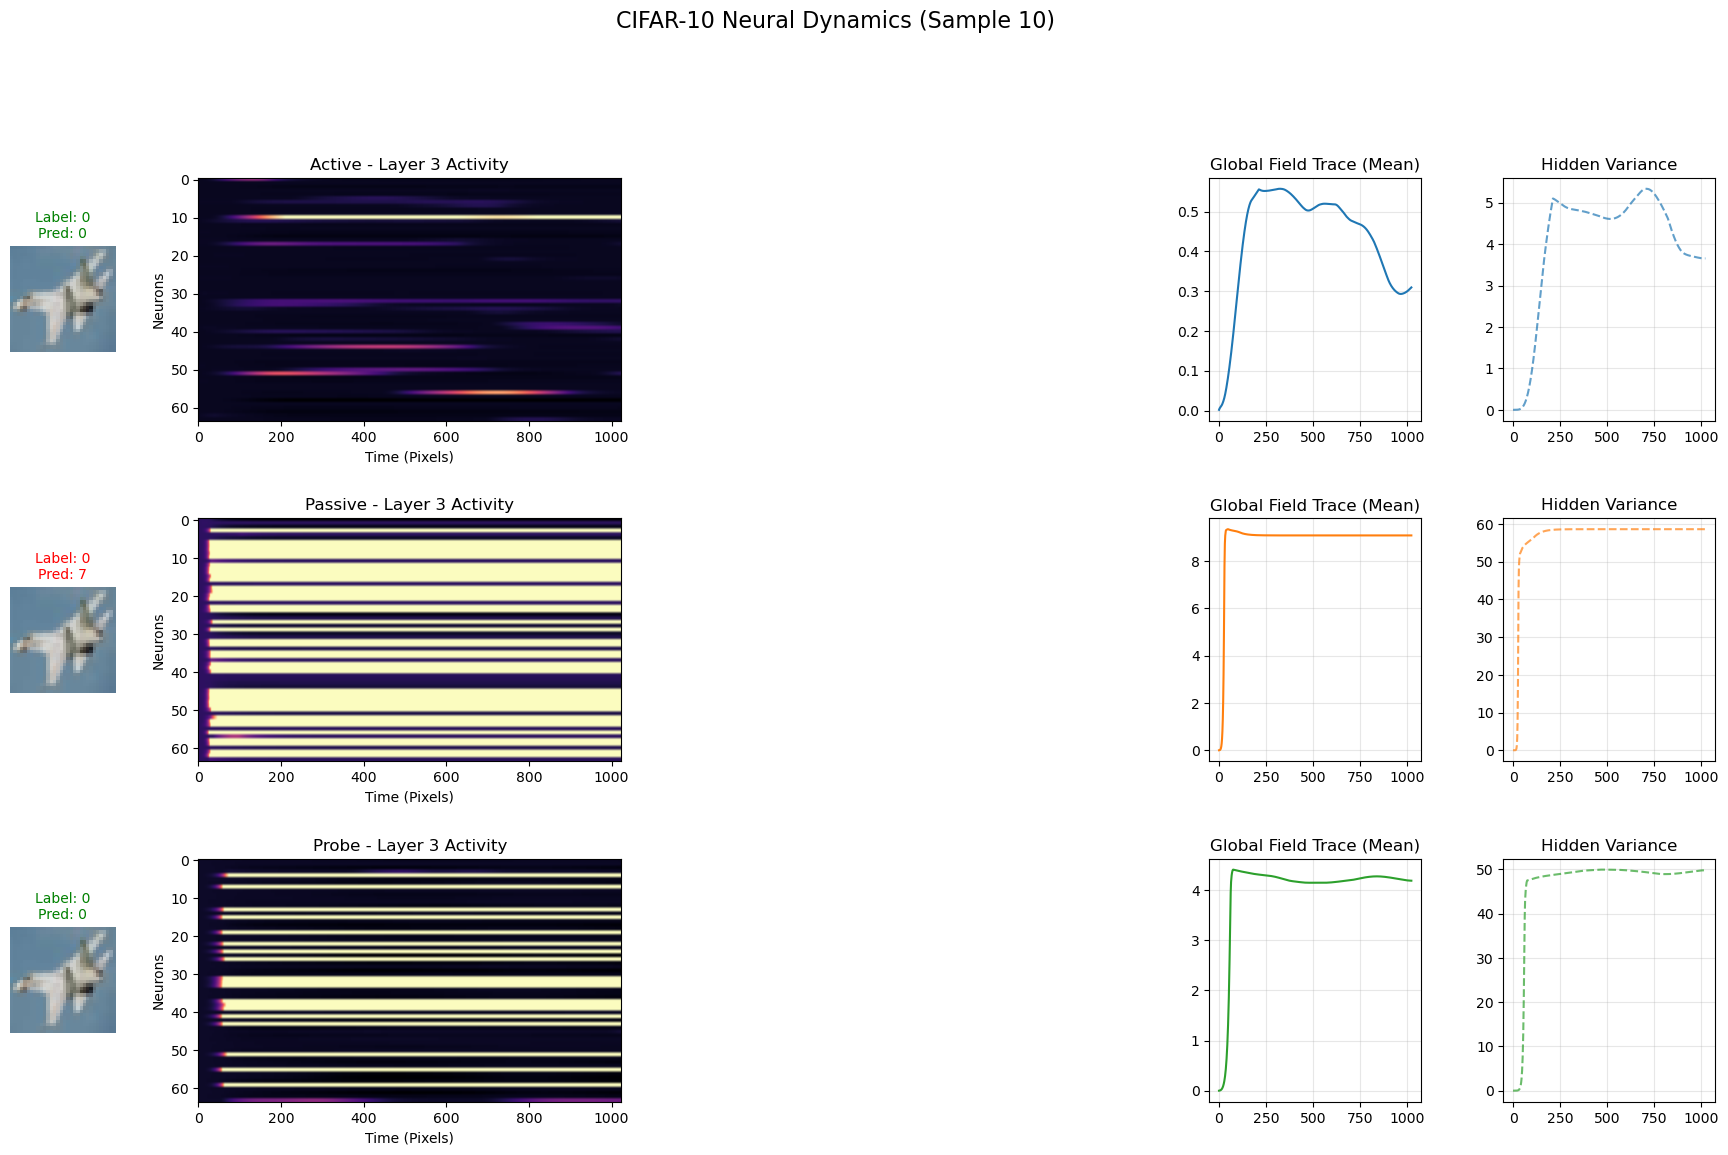

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tensorflow as tf
import os

def plot_cifar_brain(sample_idx=0, layer=2):
    """Visualizes hidden state dynamics for a CIFAR image."""
    cfg = CONFIGS['CIFAR10']
    hp = cfg['hparams']
    
    # Use the test data loaded during your evaluation block
    # Ensure x_test_raw (0-255 uint8) and x_test_seq (0-1 float, reshaped) exist
    img_seq = x_test_seq[sample_idx:sample_idx+1] # (1, 1024, 3)
    img_disp = x_test[sample_idx]                 # (32, 32, 3)
    true_label = y_test[sample_idx]

    # Map colors for the Global Field Trace
    colors = {'Active': '#1f77b4', 'Passive': '#ff7f0e', 'Probe': '#2ca02c'}

    fig = plt.figure(figsize=(22, 4 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.4)

    for row_i, cond in enumerate(CONDITIONS):
        inner_gs = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer_gs[row_i], 
                                                   width_ratios=[1, 4, 4, 2, 2], wspace=0.3)
        
        # 1. Model Init (Fixed Key: INERTIA)
        cell_kwargs = dict(
            units=cfg['hidden'], 
            strength=hp['BASE_STRENGTH'], 
            period=hp['PERIOD'], 
            lambda_slow=hp['LAMBDA_SLOW'], 
            jitter_scale=hp['JITTER_SCALE'], 
            h_inertia=hp['INERTIA'], # Fixed from H_INERTIA to INERTIA
            mode=cond.lower()
        )
        
        # Re-build the 3-layer architecture
        inputs = tf.keras.Input(shape=(1024, 3))
        h1_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h2_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h3_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        
        x1 = h1_layer(inputs)
        x2 = h2_layer(x1)
        x3 = h3_layer(x2)
        logits = tf.keras.layers.Dense(10)(x3[:, -1, :])
        model = tf.keras.Model(inputs=inputs, outputs=[logits, x1, x2, x3])
        
        # Load weights
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath)
            out_logits, l1_act, l2_act, l3_act = model(img_seq, training=False)
            
            # Get prediction (using argmax on logits)
            pred = np.argmax(out_logits.numpy(), axis=-1)[0]
            h_data = [l1_act, l2_act, l3_act][layer][0].numpy() # [Time, Hidden]

            # --- PANELS ---
            # A. Original Image
            ax0 = fig.add_subplot(inner_gs[0])
            ax0.imshow(img_disp)
            ax0.set_title(f"Label: {true_label}\nPred: {pred}", 
                         color='green' if pred==true_label else 'red', fontsize=10)
            ax0.axis('off')

            # B. Hidden state heatmap (Neuron activity over time)
            ax1 = fig.add_subplot(inner_gs[1])
            ax1.imshow(h_data.T, aspect='auto', cmap='magma')
            ax1.set_ylabel("Neurons")
            ax1.set_xlabel("Time (Pixels)")
            ax1.set_title(f"{cond} - Layer {layer+1} Activity")

            # C. Population Mean (The "Global Field" Trace)
            ax2 = fig.add_subplot(inner_gs[3])
            ax2.plot(np.mean(h_data, axis=-1), color=colors.get(cond, 'black'), lw=1.5)
            ax2.set_title("Global Field Trace (Mean)")
            ax2.grid(alpha=0.3)
            
            # D. Variance / Energy Trace
            ax3 = fig.add_subplot(inner_gs[4])
            ax3.plot(np.var(h_data, axis=-1), color=colors.get(cond, 'black'), linestyle='--', alpha=0.7)
            ax3.set_title("Hidden Variance")
            ax3.grid(alpha=0.3)
        else:
            print(f"Skipping {cond}: Weights not found.")

    plt.suptitle(f"CIFAR-10 Neural Dynamics (Sample {sample_idx})", y=1.02, fontsize=16)
    plt.show()

# Example usage:
plot_cifar_brain(sample_idx=2, layer=3)

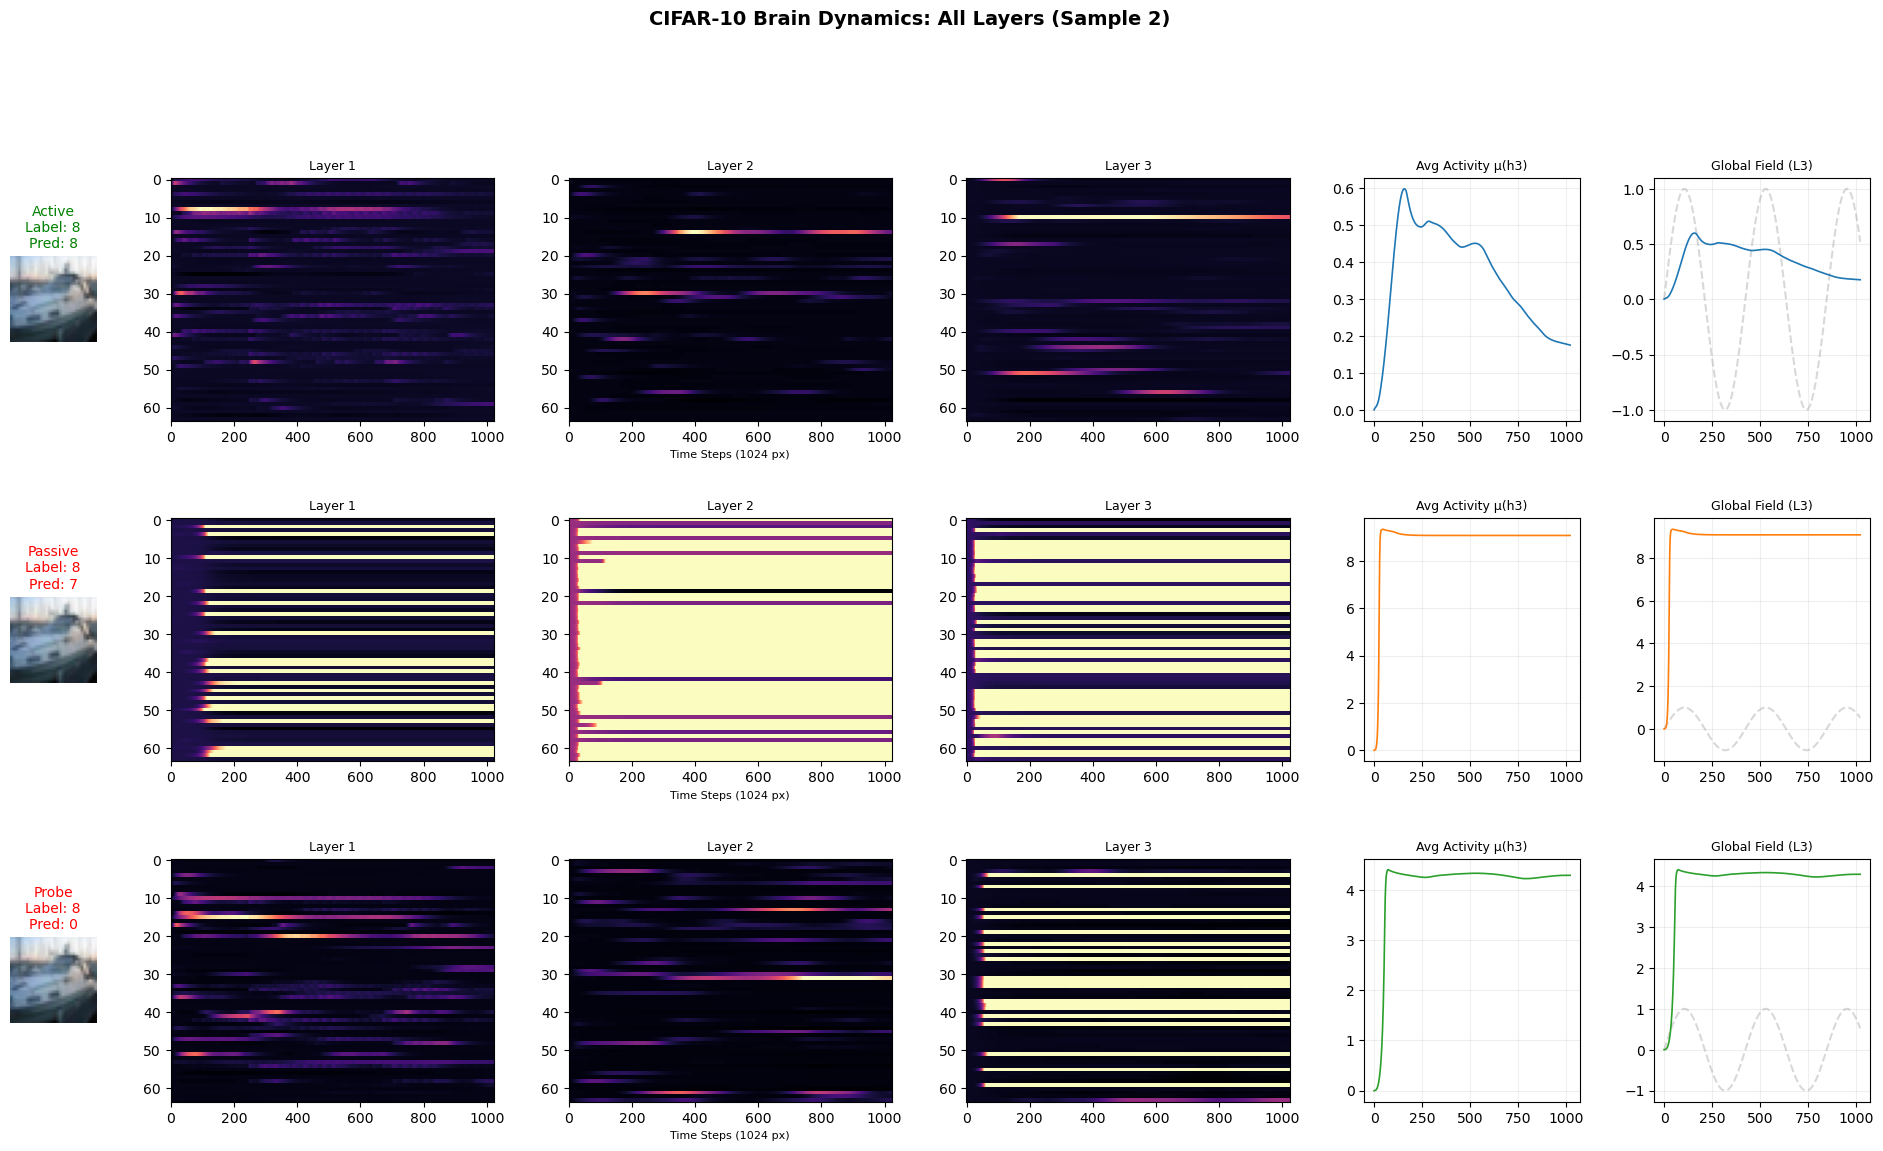

In [11]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os

def plot_cifar_brain_all_layers(sample_idx=10):
    """
    Visualizes hidden state dynamics for ALL layers of CIFAR-10.
    Replicates the MNIST 'plot_brain' layout for the 1024-step sequence.
    """
    cfg = CONFIGS['CIFAR10']
    hp = cfg['hparams']
    
    # Setup data (Assuming x_test and x_test_seq are in global scope)
    img_seq = x_test_seq[sample_idx:sample_idx+1] # (1, 1024, 3)
    img_disp = x_test[sample_idx]                 # (32, 32, 3)
    true_label = y_test[sample_idx]

    # Colors for conditions
    COLORS = {'Active': '#1f77b4', 'Passive': '#ff7f0e', 'Probe': '#2ca02c'}

    fig = plt.figure(figsize=(24, 4 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.4)

    for row_i, cond in enumerate(CONDITIONS):
        # Grid: [Image, L1 Heatmap, L2 Heatmap, L3 Heatmap, Pop Mean, GF Recon]
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[0.8, 3, 3, 3, 2, 2], wspace=0.3
        )

        # 1. Build Model Instance for this condition
        cell_kwargs = dict(
            units=cfg['hidden'], strength=hp['BASE_STRENGTH'], period=hp['PERIOD'], 
            lambda_slow=hp['LAMBDA_SLOW'], jitter_scale=hp['JITTER_SCALE'], 
            h_inertia=hp['INERTIA'], mode=cond.lower()
        )
        
        inputs = tf.keras.Input(shape=(1024, 3))
        h1_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h2_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h3_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        
        x1 = h1_layer(inputs)
        x2 = h2_layer(x1)
        x3 = h3_layer(x2)
        logits = tf.keras.layers.Dense(10)(x3[:, -1, :])
        model = tf.keras.Model(inputs=inputs, outputs=[logits, x1, x2, x3])
        
        # 2. Load Weights
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath)
            out_logits, l1_act, l2_act, l3_act = model(img_seq, training=False)
            
            pred = np.argmax(out_logits.numpy(), axis=-1)[0]
            h_layers = [l1_act[0].numpy(), l2_act[0].numpy(), l3_act[0].numpy()]

            # --- RENDER PANELS ---
            
            # PANEL 0: Original CIFAR Image
            ax0 = fig.add_subplot(inner_gs[0])
            ax0.imshow(img_disp)
            ax0.set_title(f'{cond}\nLabel: {true_label}\nPred: {pred}', 
                         color='green' if pred == true_label else 'red', fontsize=10)
            ax0.axis('off')

            # PANEL 1-3: Heatmaps for L1, L2, L3
            for li, (h_data, lbl) in enumerate(zip(h_layers, ['Layer 1', 'Layer 2', 'Layer 3'])):
                ax = fig.add_subplot(inner_gs[li + 1])
                # Transpose to [Neurons, Time] for visualization
                ax.imshow(h_data.T, aspect='auto', cmap='magma', interpolation='nearest')
                ax.set_title(lbl, fontsize=9)
                if li == 1: ax.set_xlabel('Time Steps (1024 px)', fontsize=8)

            # PANEL 4: Population Mean Trace (Top Layer)
            ax_pm = fig.add_subplot(inner_gs[4])
            pop_mean = np.mean(h_layers[2], axis=-1)
            ax_pm.plot(pop_mean, color=COLORS.get(cond, 'black'), lw=1.2)
            ax_pm.set_title('Avg Activity μ(h3)', fontsize=9)
            ax_pm.grid(alpha=0.2)

            # PANEL 5: Reconstructed Global Field (Targeting Layer 3)
            # Replicates the sine wave oscillator vs. the actual field feedback
            ax_fe = fig.add_subplot(inner_gs[5])
            
            # Reconstruction logic based on hparams
            time_steps = np.arange(1024)
            phase = time_steps * (2.0 * np.pi / hp['PERIOD'])
            oscillator = np.sin(phase)
            
            # Field reconstruction: Mean across neurons of the current activity
            ax_fe.plot(oscillator, color='gray', alpha=0.3, ls='--', label='Osc')
            ax_fe.plot(pop_mean, color=COLORS.get(cond, 'black'), lw=1.2, label='GF')
            ax_fe.set_title('Global Field (L3)', fontsize=9)
            ax_fe.grid(alpha=0.2)

        else:
            print(f"File {wpath} not found.")

    plt.suptitle(f"CIFAR-10 Brain Dynamics: All Layers (Sample {sample_idx})", y=1.02, fontsize=14, fontweight='bold')
    plt.show()

# Execution
plot_cifar_brain_all_layers(sample_idx=2)

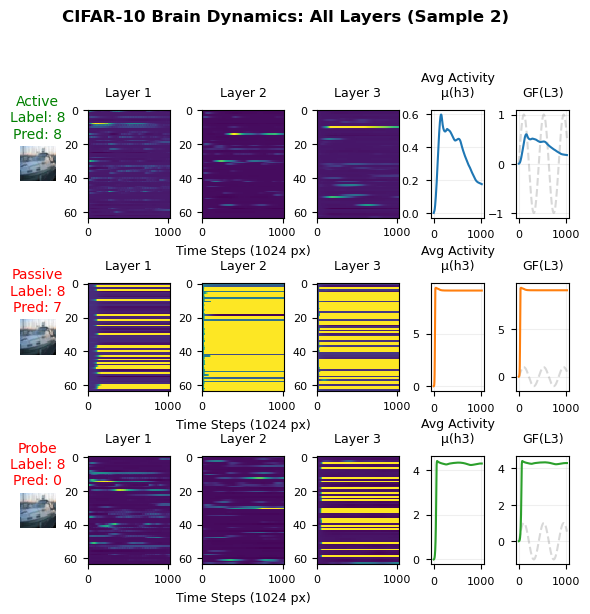

In [21]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from matplotlib import cm

def plot_cifar_brain_all_layers(sample_idx=2):
    """
    Visualizes hidden state dynamics for ALL layers of CIFAR-10.
    Larger sample image size, compatible with Elsevier's figure requirements.
    """
    cfg = CONFIGS['CIFAR10']
    hp = cfg['hparams']

    img_seq = x_test_seq[sample_idx:sample_idx+1]  # (1, 1024, 3)
    img_disp = x_test[sample_idx]                 # (32, 32, 3)
    true_label = y_test[sample_idx]

    COLORS = {'Active': '#1f77b4', 'Passive': '#ff7f0e', 'Probe': '#2ca02c'}

    # Increase figure height and width to accommodate larger image
    fig = plt.figure(figsize=(18/2.54, 5 * len(CONDITIONS) / 2.54))  # Increased width from 17 to 18 cm

    # Increase vertical spacing between rows
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.6)

    for row_i, cond in enumerate(CONDITIONS):
        # Adjust width_ratios to give more space to the image panel (first panel)
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[1.2, 2.8, 2.8, 2.8, 1.8, 1.8], wspace=0.5  # Increased first ratio from 0.8 to 1.2, others adjusted
        )

        cell_kwargs = dict(
            units=cfg['hidden'], strength=hp['BASE_STRENGTH'], period=hp['PERIOD'],
            lambda_slow=hp['LAMBDA_SLOW'], jitter_scale=hp['JITTER_SCALE'],
            h_inertia=hp['INERTIA'], mode=cond.lower()
        )

        inputs = tf.keras.Input(shape=(1024, 3))
        h1_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h2_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h3_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)

        x1 = h1_layer(inputs)
        x2 = h2_layer(x1)
        x3 = h3_layer(x2)
        logits = tf.keras.layers.Dense(10)(x3[:, -1, :])
        model = tf.keras.Model(inputs=inputs, outputs=[logits, x1, x2, x3])

        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath)
            out_logits, l1_act, l2_act, l3_act = model(img_seq, training=False)

            pred = np.argmax(out_logits.numpy(), axis=-1)[0]
            h_layers = [l1_act[0].numpy(), l2_act[0].numpy(), l3_act[0].numpy()]

            # PANEL 0: Original CIFAR Image - Larger size
            ax0 = fig.add_subplot(inner_gs[0])
            ax0.imshow(img_disp, interpolation='none')  # interpolation='none' for pixelated but larger image
            ax0.set_title(f'{cond}\nLabel: {true_label}\nPred: {pred}',
                         color='green' if pred == true_label else 'red', fontsize=10)
            ax0.axis('off')

            # PANEL 1-3: Heatmaps for L1, L2, L3
            for li, (h_data, lbl) in enumerate(zip(h_layers, ['Layer 1', 'Layer 2', 'Layer 3'])):
                ax = fig.add_subplot(inner_gs[li + 1])
                ax.imshow(h_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
                ax.set_title(lbl, fontsize=9, pad=10)
                ax.tick_params(axis='both', which='major', labelsize=8)
                if li == 1: ax.set_xlabel('Time Steps (1024 px)', fontsize=9, labelpad=5)

            # PANEL 4: Population Mean Trace
            ax_pm = fig.add_subplot(inner_gs[4])
            pop_mean = np.mean(h_layers[2], axis=-1)
            ax_pm.plot(pop_mean, color=COLORS.get(cond, 'black'), lw=1.5)
            ax_pm.set_title('Avg Activity\nμ(h3)', fontsize=9, pad=10)
            ax_pm.grid(alpha=0.2)
            ax_pm.tick_params(axis='both', which='major', labelsize=8, pad=5)

            # PANEL 5: Reconstructed Global Field
            ax_fe = fig.add_subplot(inner_gs[5])
            time_steps = np.arange(1024)
            phase = time_steps * (2.0 * np.pi / hp['PERIOD'])
            oscillator = np.sin(phase)

            ax_fe.plot(oscillator, color='gray', alpha=0.3, ls='--', label='Osc', lw=1.5)
            ax_fe.plot(pop_mean, color=COLORS.get(cond, 'black'), lw=1.5, label='GF')
            ax_fe.set_title('GF(L3)', fontsize=9, pad=10)
            ax_fe.grid(alpha=0.2)
            ax_fe.tick_params(axis='both', which='major', labelsize=8, pad=5)

        else:
            print(f"File {wpath} not found.")

    plt.suptitle(f"CIFAR-10 Brain Dynamics: All Layers (Sample {sample_idx})",
                 y=1.05, fontsize=12, fontweight='bold')

    # Save with 600 DPI for higher resolution
    plt.savefig('cifar_brain_dynamics.tiff', dpi=600, bbox_inches='tight')
    plt.savefig('cifar_brain_dynamics.pdf', dpi=600, bbox_inches='tight')
    plt.show()

plot_cifar_brain_all_layers()

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
a
def plot_cifar_brain_reversed(sample_idx=10):
    """
    Visualizes hidden state dynamics for ALL layers of CIFAR-10 using REVERSED sequences.
    Shows the model's internal response when the pixel stream is flipped.
    """
    cfg = CONFIGS['CIFAR10']
    hp = cfg['hparams']
    
    # Setup data
    # img_seq is the standard sequence (1, 1024, 3)
    img_seq_std = x_test_seq[sample_idx:sample_idx+1] 
    # The Reversal: flip along the time dimension (axis 1)
    img_seq_rev = img_seq_std[:, ::-1, :]
    
    img_disp = x_test[sample_idx] # Original image for display
    true_label = y_test[sample_idx]

    COLORS = {'Active': '#1f77b4', 'Passive': '#ff7f0e', 'Probe': '#2ca02c'}

    fig = plt.figure(figsize=(24, 4 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.4)

    for row_i, cond in enumerate(CONDITIONS):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[0.8, 3, 3, 3, 2, 2], wspace=0.3
        )

        # 1. Build Model Instance
        cell_kwargs = dict(
            units=cfg['hidden'], strength=hp['BASE_STRENGTH'], period=hp['PERIOD'], 
            lambda_slow=hp['LAMBDA_SLOW'], jitter_scale=hp['JITTER_SCALE'], 
            h_inertia=hp['INERTIA'], mode=cond.lower()
        )
        
        inputs = tf.keras.Input(shape=(1024, 3))
        h1_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h2_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h3_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        
        x1 = h1_layer(inputs)
        x2 = h2_layer(x1)
        x3 = h3_layer(x2)
        logits = tf.keras.layers.Dense(10)(x3[:, -1, :])
        model = tf.keras.Model(inputs=inputs, outputs=[logits, x1, x2, x3])
        
        # 2. Load Weights
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath)
            
            # INFERENCE ON REVERSED DATA
            out_logits, l1_act, l2_act, l3_act = model(img_seq_rev, training=False)
            
            pred = np.argmax(out_logits.numpy(), axis=-1)[0]
            h_layers = [l1_act[0].numpy(), l2_act[0].numpy(), l3_act[0].numpy()]

            # --- RENDER PANELS ---
            
            # PANEL 0: Original Image (Note: we show standard image even though input was reversed)
            ax0 = fig.add_subplot(inner_gs[0])
            img_disp = x_test[sample_idx].reshape(-1, 3)[::-1].reshape(32, 32, 3)
            ax0.imshow(img_disp)
            ax0.set_title(f'{cond} (REV)\nLabel: {true_label}\nPred: {pred}', 
                         color='green' if pred == true_label else 'red', fontsize=10)
            ax0.axis('off')

            # PANEL 1-3: Heatmaps for L1, L2, L3 (Processing the reversed stream)
            for li, (h_data, lbl) in enumerate(zip(h_layers, ['Layer 1', 'Layer 2', 'Layer 3'])):
                ax = fig.add_subplot(inner_gs[li + 1])
                ax.imshow(h_data[::-1].T, aspect='auto', cmap='magma', interpolation='nearest')
                ax.set_title(f"{lbl} (Reversed In)", fontsize=9)
                if li == 1: ax.set_xlabel('Time Steps (Reversed Pixels)', fontsize=8)

            # PANEL 4: Population Mean Trace (Top Layer)
            ax_pm = fig.add_subplot(inner_gs[4])
            pop_mean = np.mean(h_layers[2], axis=-1)[::-1]
            ax_pm.plot(pop_mean, color=COLORS.get(cond, 'black'), lw=1.2)
            ax_pm.set_title('μ(h3) - Rev Stream', fontsize=9)
            ax_pm.grid(alpha=0.2)

            # PANEL 5: Reconstructed Global Field
            ax_fe = fig.add_subplot(inner_gs[5])
            time_steps = np.arange(1024)[::-1]
            phase = time_steps * (2.0 * np.pi / hp['PERIOD'])
            oscillator = np.sin(phase)
            
            ax_fe.plot(oscillator, color='gray', alpha=0.3, ls='--', label='Osc')
            ax_fe.plot(pop_mean, color=COLORS.get(cond, 'black'), lw=1.2, label='GF')
            ax_fe.set_title('Global Field (L3)', fontsize=9)
            ax_fe.grid(alpha=0.2)

        else:
            print(f"File {wpath} not found.")

    plt.suptitle(f"CIFAR-10 Brain Dynamics: REVERSED SEQUENCE (Sample {sample_idx})", y=1.02, fontsize=14, fontweight='bold')
    plt.show()

# Execution
plot_cifar_brain_reversed(sample_idx=2)

NameError: name 'x_test_seq' is not defined

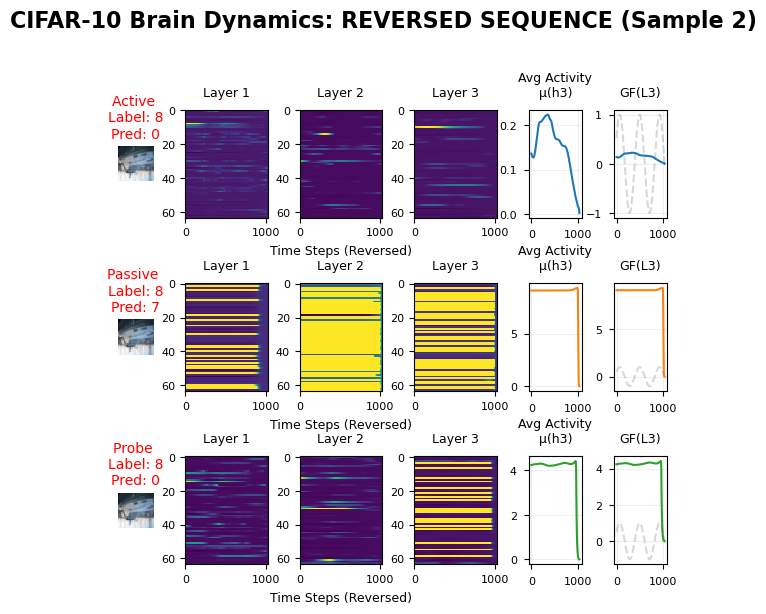

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from matplotlib import cm

def plot_cifar_brain_reversed(sample_idx=2):
    """
    Visualizes hidden state dynamics for ALL layers of CIFAR-10 using REVERSED sequences.
    Matches the style of plot_cifar_brain_all_layers but for inverted input.
    """
    FONTSIZE = 13

    cfg = CONFIGS['CIFAR10']
    hp = cfg['hparams']

    img_seq_std = x_test_seq[sample_idx:sample_idx+1]  # Standard sequence (1, 1024, 3)
    img_seq_rev = img_seq_std[:, ::-1, :]  # Reversed sequence (flip along time axis)
    img_disp = x_test[sample_idx]  # Original image for display
    img_disp = x_test[sample_idx].reshape(-1, 3)[::-1].reshape(32, 32, 3)
    true_label = y_test[sample_idx]

    COLORS = {'Active': '#1f77b4', 'Passive': '#ff7f0e', 'Probe': '#2ca02c'}

    # Match the figure size and spacing of plot_cifar_brain_all_layers
    fig = plt.figure(figsize=(18/2.54, 5 * len(CONDITIONS) / 2.54))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.6)

    for row_i, cond in enumerate(CONDITIONS):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[1.2, 2.8, 2.8, 2.8, 1.8, 1.8], wspace=0.5
        )

        cell_kwargs = dict(
            units=cfg['hidden'], strength=hp['BASE_STRENGTH'], period=hp['PERIOD'],
            lambda_slow=hp['LAMBDA_SLOW'], jitter_scale=hp['JITTER_SCALE'],
            h_inertia=hp['INERTIA'], mode=cond.lower()
        )

        inputs = tf.keras.Input(shape=(1024, 3))
        h1_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h2_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)
        h3_layer = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True)

        x1 = h1_layer(inputs)
        x2 = h2_layer(x1)
        x3 = h3_layer(x2)
        logits = tf.keras.layers.Dense(10)(x3[:, -1, :])
        model = tf.keras.Model(inputs=inputs, outputs=[logits, x1, x2, x3])

        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath)
            out_logits, l1_act, l2_act, l3_act = model(img_seq_rev, training=False)

            pred = np.argmax(out_logits.numpy(), axis=-1)[0]
            h_layers = [l1_act[0].numpy(), l2_act[0].numpy(), l3_act[0].numpy()]

            # PANEL 0: Original CIFAR Image (not reversed for display)
            ax0 = fig.add_subplot(inner_gs[0])
            ax0.imshow(img_disp, interpolation='none')
            
            ax0.set_title(f'{cond} \nLabel: {true_label}\nPred: {pred}',
                         color='green' if pred == true_label else 'red', fontsize=FONTSIZE)
            ax0.axis('off')

            # PANEL 1-3: Heatmaps for L1, L2, L3 (reversed input)
            for li, (h_data, lbl) in enumerate(zip(h_layers, ['Layer 1', 'Layer 2', 'Layer 3'])):
                ax = fig.add_subplot(inner_gs[li + 1])
                # Reverse the time axis for visualization to match input reversal
                ax.imshow(h_data[::-1].T, aspect='auto', cmap='viridis', interpolation='nearest')
                ax.set_title(f'{lbl}', fontsize=FONTSIZE, pad=10)
                ax.tick_params(axis='both', which='major', labelsize=FONTSIZE-1)
                if li == 1: ax.set_xlabel('Time Steps (Reversed)', fontsize=FONTSIZE, labelpad=5)

            # PANEL 4: Population Mean Trace (reversed)
            ax_pm = fig.add_subplot(inner_gs[4])
            pop_mean = np.mean(h_layers[2], axis=-1)[::-1]  # Reverse to match input
            ax_pm.plot(pop_mean, color=COLORS.get(cond, 'black'), lw=1.5)
            ax_pm.set_title('Avg Activity\nμ(h3)', fontsize=FONTSIZE, pad=10)
            ax_pm.grid(alpha=0.2)
            ax_pm.tick_params(axis='both', which='major', labelsize=8, pad=5)

            # PANEL 5: Reconstructed Global Field (reversed)
            ax_fe = fig.add_subplot(inner_gs[5])
            time_steps = np.arange(1024)[::-1]  # Reverse time steps
            phase = time_steps * (2.0 * np.pi / hp['PERIOD'])
            oscillator = np.sin(phase)

            ax_fe.plot(oscillator, color='gray', alpha=0.3, ls='--', label='Osc', lw=1.5)
            ax_fe.plot(pop_mean, color=COLORS.get(cond, 'black'), lw=1.5, label='GF')
            ax_fe.set_title('GF(L3)', fontsize=FONTSIZE, pad=10)
            ax_fe.grid(alpha=0.2)
            ax_fe.tick_params(axis='both', which='major', labelsize=8, pad=5)

        else:
            print(f"File {wpath} not found.")

    plt.suptitle(f"CIFAR-10 Brain Dynamics: REVERSED SEQUENCE (Sample {sample_idx})",
                 y=1.05, fontsize=16, fontweight='bold')

    plt.savefig('cifar_brain_dynamics_reversed.tiff', dpi=600, bbox_inches='tight')
    plt.savefig('cifar_brain_dynamics_reversed.pdf', dpi=600, bbox_inches='tight')
    plt.show()

plot_cifar_brain_reversed()